# Sunlit vs. shaded forest spectral unmixing

Standalone workflow for an ENVI hyperspectral image (`.bsq` + `.hdr`):

1. read wavelengths from the header;
2. define forest/vegetation pixels;
3. calculate the Normalized Difference Canopy Shadow Index (NDCSI) (Xu et al. 2019);
4. select sunlit and shaded support pixels;
5. derive one median endmember per class;
6. estimate `f_sun_veg` with a two-endmember linear model and save RMSE.

If no forest mask is available, NDVI is used only as a fallback vegetation selector.


## 1. User settings

Edit the input paths and, if needed, the main thresholds below. The most important parameters are the vegetation/forest threshold, NDCSI tail quantiles, number of support pixels, and unmixing wavelength range.


In [ ]:
from pathlib import Path

# -----------------------------------------------------------------------------
# Input / output
# -----------------------------------------------------------------------------
BSQ_PATH = Path(r"E:/Proj1_Pfynwald_Data/HyPlant/Kranzberg/20230618-KRA-1057-1111-MOSAIC-0350-L1-L4-DUAL-rect_img_atm_pol_georect_subset_warped_spa_sub_core25_spec_sub_372_1000_357_bands.bsq")
HDR_PATH = Path(r"E:/Proj1_Pfynwald_Data/HyPlant/Kranzberg/20230618-KRA-1057-1111-MOSAIC-0350-L1-L4-DUAL-rect_img_atm_pol_georect_subset_warped_spa_sub_core25_spec_sub_372_1000_357_bands.hdr")
OUT_DIR = Path(r"E:/Proj1_Pfynwald_Data/HyPlant/Kranzberg/output_sun_shade")

# Optional forest-fraction (0..1) or binary forest (0/1) raster.
# It must have exactly the same CRS, transform, width and height as the BSQ.
FOREST_FRACTION_PATH = None

# -----------------------------------------------------------------------------
# Reflectance storage / validity
# -----------------------------------------------------------------------------
REFLECTANCE_SCALE = 10000.0   # set to 1.0 if the BSQ already stores 0..1 reflectance
NODATA_VALUE = None           # None = use nodata from raster metadata
VALID_REFLECTANCE_RANGE = (0.0, 1.0)
OUTPUT_NODATA = -9999.0

# -----------------------------------------------------------------------------
# Vegetation / forest domain
# -----------------------------------------------------------------------------
FOREST_FRACTION_MIN = None
VEG_NDVI_MIN = 0.50           # used ONLY if FOREST_FRACTION_PATH is None

# -----------------------------------------------------------------------------
# Spectral ranges [nm]
# -----------------------------------------------------------------------------
RED_RANGE = (650.0, 680.0)
NIR_RANGE = (780.0, 900.0)
RED_EDGE_SEARCH_RANGE = (680.0, 750.0)
RED_EDGE_HALF_WIDTH_NM = 2.5

# Robust scaling of red-edge reflectance in NDCSI
NDCSI_LOW_QUANTILE = 0.01
NDCSI_HIGH_QUANTILE = 0.99

# Candidate tails in NDCSI
SUN_NDCSI_QUANTILE = 0.85
SHADE_NDCSI_QUANTILE = 0.15

# Final support set used to construct each median endmember
ENDMEMBER_SUPPORT_SIZE = 40   # Final support pixels per class
MIN_SUPPORT_REQUIRED = 20     # Minimum valid spectra required
MIN_SPACING_PIXELS = 2        # Minimum spacing between support pixels
MAX_RED_EDGE_SAMPLES = 3000   # Max spectra for red-edge estimation
RANDOM_SEED = 42              # Reproducible sampling

# Final two-endmember fit
UNMIXING_RANGE = (400.0, 1100.0)   # Wavelength range used for fitting
EXCLUDE_RANGES = ()                 # Wavelength ranges to ignore
BLOCK_ROWS = 64                     # Rows processed per block

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUT_DIR}")

Output directory: E:\Proj1_Pfynwald_Data\HyPlant\Kranzberg\output_sun_shade


## 2. Imports

Required packages: NumPy, Rasterio, Matplotlib, GeoPandas and Shapely.


In [9]:
import json
import re
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.windows import Window
from shapely.geometry import Point

print("Imports successful.")

Imports successful.


## 3. Read wavelengths from .hdr

In [10]:
def read_envi_wavelengths(hdr_path: Path):
    """Read wavelength values from an ENVI header and return nanometres."""
    hdr_path = Path(hdr_path)
    try:
        text = hdr_path.read_text(encoding="utf-8")
    except UnicodeDecodeError:
        text = hdr_path.read_text(encoding="latin-1")

    m = re.search(r"(?is)\bwavelength\s*=\s*\{(.*?)\}", text)
    if m is None:
        raise ValueError(f"No 'wavelength = {{...}}' field found in {hdr_path}")

    values = [
        float(v.strip())
        for v in m.group(1).replace("\n", " ").split(",")
        if v.strip()
    ]
    wavelengths = np.asarray(values, dtype="float64")

    units_match = re.search(
        r"(?im)^\s*wavelength\s+units\s*=\s*([^\r\n]+)", text
    )
    units = units_match.group(1).strip().strip("{} ") if units_match else ""
    units_lower = units.lower()

    if "micro" in units_lower or "µm" in units_lower or "um" == units_lower:
        wavelengths *= 1000.0
    elif not units and np.nanmedian(wavelengths) < 10:
        # Common ENVI case when units are omitted but values are in micrometres.
        wavelengths *= 1000.0
        units = "inferred micrometres"

    bands_match = re.search(r"(?im)^\s*bands\s*=\s*(\d+)", text)
    hdr_bands = int(bands_match.group(1)) if bands_match else None

    return wavelengths, units, hdr_bands


wavelengths, wavelength_units, hdr_band_count = read_envi_wavelengths(HDR_PATH)

with rasterio.open(BSQ_PATH) as src:
    raster_info = {
        "bands": src.count,
        "shape": (src.height, src.width),
        "dtype": src.dtypes[0],
        "crs": str(src.crs),
        "resolution": src.res,
        "nodata": src.nodata,
    }

if len(wavelengths) != raster_info["bands"]:
    raise ValueError(
        f"Header contains {len(wavelengths)} wavelengths but raster has "
        f"{raster_info['bands']} bands."
    )
if hdr_band_count is not None and hdr_band_count != raster_info["bands"]:
    raise ValueError(
        f"Header says bands={hdr_band_count}, raster has {raster_info['bands']} bands."
    )

print(f"Raster: {BSQ_PATH}")
print(f"Bands: {raster_info['bands']}")
print(f"Shape: {raster_info['shape']}")
print(f"Resolution: {raster_info['resolution']}")
print(f"CRS: {raster_info['crs']}")
print(f"Raster nodata: {raster_info['nodata']}")
print(f"Wavelength range: {wavelengths.min():.1f}–{wavelengths.max():.1f} nm")
print(f"Wavelength units in header: {wavelength_units or 'not stated'}")

Raster: E:\Proj1_Pfynwald_Data\HyPlant\Kranzberg\20230618-KRA-1057-1111-MOSAIC-0350-L1-L4-DUAL-rect_img_atm_pol_georect_subset_warped_spa_sub_core25_spec_sub_372_1000_357_bands.bsq
Bands: 357
Shape: (700, 700)
Resolution: (0.5, 0.5)
CRS: EPSG:32632
Raster nodata: -999.0
Wavelength range: 373.4–1000.2 nm
Wavelength units in header: Unknown


## 4. Helper functions

Utilities for band selection, reflectance scaling, spectral sampling and GeoTIFF export.


In [11]:
def band_indices_for_range(wavelengths, spectral_range):
    wl = np.asarray(wavelengths, dtype=float)
    low, high = spectral_range
    idx = np.flatnonzero((wl >= low) & (wl <= high))
    if idx.size == 0:
        center = 0.5 * (low + high)
        idx = np.asarray([int(np.argmin(np.abs(wl - center)))])
    return idx


def scaled_reflectance(raw, src_nodata=None):
    """Convert stored values to reflectance and set invalid values to NaN."""
    raw = np.asarray(raw)
    arr = raw.astype("float32", copy=True)

    invalid = ~np.isfinite(arr)
    nodata = NODATA_VALUE if NODATA_VALUE is not None else src_nodata
    if nodata is not None:
        invalid |= raw == nodata

    arr /= float(REFLECTANCE_SCALE)
    lo, hi = VALID_REFLECTANCE_RANGE
    invalid |= (arr < lo) | (arr > hi)
    arr[invalid] = np.nan
    return arr


def read_mean_reflectance(src_path, wavelengths, spectral_range):
    """Mean reflectance across all bands falling in a wavelength interval."""
    idx = band_indices_for_range(wavelengths, spectral_range)
    with rasterio.open(src_path) as src:
        raw = src.read((idx + 1).tolist())
        arr = scaled_reflectance(raw, src.nodata)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        return np.nanmean(arr, axis=0).astype("float32")


def sample_spectra(src_path, rows, cols, expected_bands):
    """Sample full spectra at raster row/column positions."""
    rows = np.asarray(rows, dtype=int)
    cols = np.asarray(cols, dtype=int)
    if rows.size == 0:
        return np.empty((0, expected_bands), dtype="float32")

    with rasterio.open(src_path) as src:
        if src.count != expected_bands:
            raise ValueError("Raster band count changed unexpectedly.")
        xs, ys = rasterio.transform.xy(src.transform, rows, cols, offset="center")
        coords = list(zip(xs, ys))
        raw = np.asarray(list(src.sample(coords)), dtype="float32")
        spectra = scaled_reflectance(raw, src.nodata)
    return spectra


def robust_spectral_stats(spectra, label):
    """Median and 10th/90th percentiles after removing incomplete spectra."""
    if spectra.ndim != 2 or spectra.shape[0] == 0:
        raise ValueError(f"No spectra available for {label}.")

    complete = np.isfinite(spectra).mean(axis=1) >= 0.98
    spectra = spectra[complete]
    if spectra.shape[0] == 0:
        raise ValueError(f"No sufficiently complete spectra remain for {label}.")

    return {
        "median": np.nanmedian(spectra, axis=0).astype("float32"),
        "p10": np.nanpercentile(spectra, 10, axis=0).astype("float32"),
        "p90": np.nanpercentile(spectra, 90, axis=0).astype("float32"),
        "n": int(spectra.shape[0]),
    }


def write_single_band_tif(out_path, values, description):
    """Write a float32 raster on exactly the original hyperspectral grid."""
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    with rasterio.open(BSQ_PATH) as src:
        profile = {
            "driver": "GTiff",
            "height": src.height,
            "width": src.width,
            "count": 1,
            "dtype": "float32",
            "crs": src.crs,
            "transform": src.transform,
            "nodata": OUTPUT_NODATA,
            "compress": "deflate",
            "BIGTIFF": "IF_SAFER",
        }

    data = np.where(np.isfinite(values), values, OUTPUT_NODATA).astype("float32")
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(data, 1)
        dst.set_band_description(1, description)


def load_forest_fraction_on_exact_grid(path):
    """Load an optional 0..1 (or 0/1) forest raster and verify exact alignment."""
    with rasterio.open(BSQ_PATH) as ref, rasterio.open(path) as src:
        if src.crs != ref.crs:
            raise ValueError("Forest mask CRS does not match the hyperspectral raster.")
        if (src.height, src.width) != (ref.height, ref.width):
            raise ValueError("Forest mask shape does not match the hyperspectral raster.")
        if not src.transform.almost_equals(ref.transform):
            raise ValueError("Forest mask transform/grid does not match the hyperspectral raster.")
        return src.read(1, masked=True).filled(np.nan).astype("float32")

print("Helper functions ready.")

Helper functions ready.


## 5. Define the forest/vegetation domain

If a forest-fraction raster is supplied, use `forest_fraction >= FOREST_FRACTION_MIN`. Otherwise use `NDVI >= VEG_NDVI_MIN` as a fallback.


In [12]:
red = read_mean_reflectance(BSQ_PATH, wavelengths, RED_RANGE)
nir = read_mean_reflectance(BSQ_PATH, wavelengths, NIR_RANGE)

den = nir + red
ndvi = np.full(red.shape, np.nan, dtype="float32")
valid_den = np.isfinite(red) & np.isfinite(nir) & (np.abs(den) > 1e-8)
ndvi[valid_den] = (nir[valid_den] - red[valid_den]) / den[valid_den]

if FOREST_FRACTION_PATH is not None:
    forest_fraction = load_forest_fraction_on_exact_grid(FOREST_FRACTION_PATH)
    analysis_mask = (
        np.isfinite(forest_fraction)
        & (forest_fraction >= FOREST_FRACTION_MIN)
        & np.isfinite(ndvi)
    )
    mask_description = f"forest fraction >= {FOREST_FRACTION_MIN:g}"
else:
    forest_fraction = None
    analysis_mask = np.isfinite(ndvi) & (ndvi >= VEG_NDVI_MIN)
    mask_description = f"NDVI >= {VEG_NDVI_MIN:g} (fallback; no forest raster supplied)"

n_pixels = int(analysis_mask.sum())
if n_pixels < MIN_SUPPORT_REQUIRED * 2:
    raise ValueError(
        f"Only {n_pixels} pixels remain in the analysis domain. "
        "Relax the forest/NDVI criterion or inspect the input scaling."
    )

write_single_band_tif(OUT_DIR / "NDVI.tif", ndvi, "NDVI")

print(f"Analysis domain: {mask_description}")
print(f"Pixels in analysis domain: {n_pixels}")
print(f"NDVI median inside domain: {np.nanmedian(ndvi[analysis_mask]):.3f}")

Analysis domain: NDVI >= 0.5 (fallback; no forest raster supplied)
Pixels in analysis domain: 488080
NDVI median inside domain: 0.924


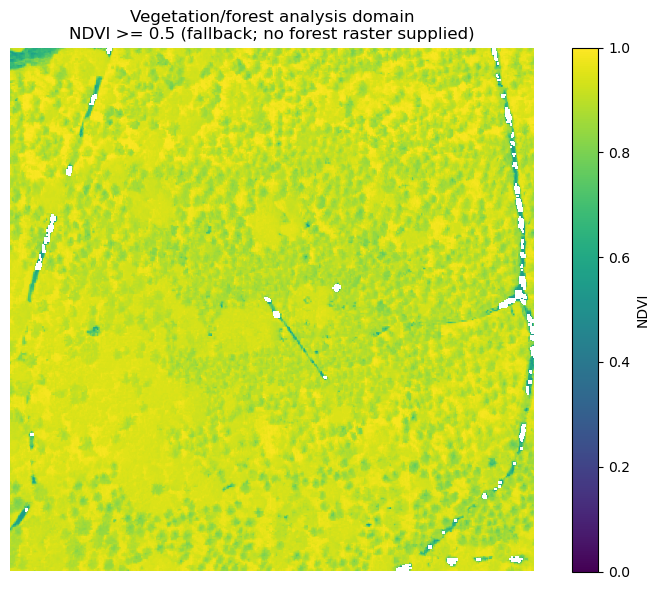

In [13]:
plt.figure(figsize=(8, 6))
plt.imshow(np.where(analysis_mask, ndvi, np.nan), vmin=0, vmax=1)
plt.colorbar(label="NDVI")
plt.title(f"Vegetation/forest analysis domain\n{mask_description}")
plt.axis("off")
plt.tight_layout()
plt.show()

## 6. Calculate NDCSI

The red edge is estimated from the scene, then NDCSI is calculated. Higher NDCSI is treated as more sunlit vegetation and lower NDCSI as more shaded vegetation.


In [14]:
rng = np.random.default_rng(RANDOM_SEED)

# Sample a manageable number of vegetation pixels for red-edge detection.
rows_all, cols_all = np.nonzero(analysis_mask)
if rows_all.size > MAX_RED_EDGE_SAMPLES:
    pick = rng.choice(rows_all.size, MAX_RED_EDGE_SAMPLES, replace=False)
    re_rows = rows_all[pick]
    re_cols = cols_all[pick]
else:
    re_rows, re_cols = rows_all, cols_all

re_spectra = sample_spectra(BSQ_PATH, re_rows, re_cols, len(wavelengths))
search_idx = band_indices_for_range(wavelengths, RED_EDGE_SEARCH_RANGE)
median_re = np.nanmedian(re_spectra[:, search_idx], axis=0)
search_wl = wavelengths[search_idx]
finite = np.isfinite(median_re) & np.isfinite(search_wl)

if finite.sum() < 3:
    raise ValueError("Too few valid bands to estimate a red-edge wavelength.")

gradient = np.gradient(median_re[finite], search_wl[finite])
red_edge_nm = float(search_wl[finite][int(np.nanargmax(gradient))])

re_range = (
    red_edge_nm - RED_EDGE_HALF_WIDTH_NM,
    red_edge_nm + RED_EDGE_HALF_WIDTH_NM,
)
rho_re = read_mean_reflectance(BSQ_PATH, wavelengths, re_range)

re_values = rho_re[analysis_mask & np.isfinite(rho_re)]
re_min = float(np.quantile(re_values, NDCSI_LOW_QUANTILE))
re_max = float(np.quantile(re_values, NDCSI_HIGH_QUANTILE))
if not np.isfinite(re_min) or not np.isfinite(re_max) or re_max <= re_min:
    raise ValueError("Invalid red-edge reflectance range for NDCSI scaling.")

ndcsi = ndvi * (rho_re - re_min) / (re_max - re_min)
ndcsi = np.clip(ndcsi, 0.0, 1.0).astype("float32")
ndcsi[~analysis_mask] = np.nan

write_single_band_tif(OUT_DIR / "NDCSI.tif", ndcsi, "NDCSI")

print(f"Detected red edge: {red_edge_nm:.2f} nm")
print(f"Red-edge averaging interval: {re_range[0]:.2f}–{re_range[1]:.2f} nm")
print(f"NDCSI red-edge scaling: q{NDCSI_LOW_QUANTILE:.2f}={re_min:.4f}, "
      f"q{NDCSI_HIGH_QUANTILE:.2f}={re_max:.4f}")

Detected red edge: 732.59 nm
Red-edge averaging interval: 730.09–735.09 nm
NDCSI red-edge scaling: q0.01=0.0311, q0.99=0.3747


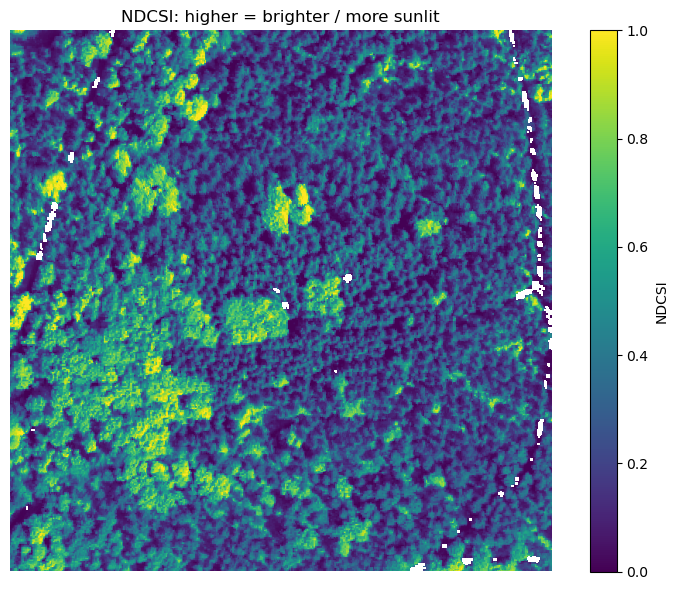

In [15]:
plt.figure(figsize=(8, 6))
plt.imshow(ndcsi, vmin=0, vmax=1)
plt.colorbar(label="NDCSI")
plt.title("NDCSI: higher = brighter / more sunlit")
plt.axis("off")
plt.tight_layout()
plt.show()

## 7. Select support pixels

The upper and lower NDCSI tails define candidate pools. A smaller, spatially distributed set is retained for each class. Their median spectra become one sunlit and one shaded endmember.


In [16]:
def select_spatial_support(candidate_mask, score_array, label):
    """Take the most extreme candidates, with optional pixel-space thinning."""
    rows, cols = np.nonzero(candidate_mask)
    values = score_array[rows, cols]
    finite = np.isfinite(values)
    rows, cols, values = rows[finite], cols[finite], values[finite]

    if label == "sunlit":
        order = np.argsort(values)[::-1]
    elif label == "shaded":
        order = np.argsort(values)
    else:
        raise ValueError(label)

    rows, cols, values = rows[order], cols[order], values[order]

    def run(spacing):
        chosen = []
        for row, col, value in zip(rows, cols, values):
            if spacing > 0:
                too_close = any(
                    max(abs(int(row) - r0), abs(int(col) - c0)) <= spacing
                    for r0, c0, _ in chosen
                )
                if too_close:
                    continue
            chosen.append((int(row), int(col), float(value)))
            if len(chosen) >= ENDMEMBER_SUPPORT_SIZE:
                break
        return chosen

    chosen = run(MIN_SPACING_PIXELS)
    if len(chosen) < MIN_SUPPORT_REQUIRED and MIN_SPACING_PIXELS > 0:
        print(
            f"WARNING: only {len(chosen)} spatially thinned {label} support pixels; "
            "retrying without the spacing constraint."
        )
        chosen = run(0)

    if len(chosen) < MIN_SUPPORT_REQUIRED:
        raise ValueError(
            f"Only {len(chosen)} {label} support pixels are available; "
            f"need at least {MIN_SUPPORT_REQUIRED}."
        )
    return chosen


ndcsi_values = ndcsi[analysis_mask & np.isfinite(ndcsi)]
sun_threshold = float(np.quantile(ndcsi_values, SUN_NDCSI_QUANTILE))
shade_threshold = float(np.quantile(ndcsi_values, SHADE_NDCSI_QUANTILE))

sun_pool = analysis_mask & np.isfinite(ndcsi) & (ndcsi >= sun_threshold)
shade_pool = analysis_mask & np.isfinite(ndcsi) & (ndcsi <= shade_threshold)

sun_support = select_spatial_support(sun_pool, ndcsi, "sunlit")
shade_support = select_spatial_support(shade_pool, ndcsi, "shaded")

print(f"Sunlit pool: {int(sun_pool.sum())} pixels, threshold NDCSI >= {sun_threshold:.3f}")
print(f"Shaded pool: {int(shade_pool.sum())} pixels, threshold NDCSI <= {shade_threshold:.3f}")
print(f"Selected sunlit support pixels: {len(sun_support)}")
print(f"Selected shaded support pixels: {len(shade_support)}")

Sunlit pool: 73212 pixels, threshold NDCSI >= 0.558
Shaded pool: 73212 pixels, threshold NDCSI <= 0.080
Selected sunlit support pixels: 40
Selected shaded support pixels: 40


In [17]:
# Save selected support pixels as a QGIS-ready GeoPackage.
records = []
with rasterio.open(BSQ_PATH) as src:
    crs = src.crs
    transform = src.transform

    for label, support in (("sunlit", sun_support), ("shaded", shade_support)):
        for rank, (row, col, value) in enumerate(support, start=1):
            x, y = rasterio.transform.xy(transform, row, col, offset="center")
            records.append(
                {
                    "class": label,
                    "rank": rank,
                    "row": row,
                    "col": col,
                    "ndcsi": value,
                    "ndvi": float(ndvi[row, col]),
                    "forest_frac": (
                        float(forest_fraction[row, col])
                        if forest_fraction is not None
                        else np.nan
                    ),
                    "geometry": Point(float(x), float(y)),
                }
            )

points = gpd.GeoDataFrame(records, geometry="geometry", crs=crs)
gpkg_path = OUT_DIR / "endmember_support_pixels.gpkg"
if gpkg_path.exists():
    gpkg_path.unlink()
points.to_file(gpkg_path, layer="endmember_pixels", driver="GPKG")
print(f"Saved support pixels: {gpkg_path}")

Saved support pixels: E:\Proj1_Pfynwald_Data\HyPlant\Kranzberg\output_sun_shade\endmember_support_pixels.gpkg


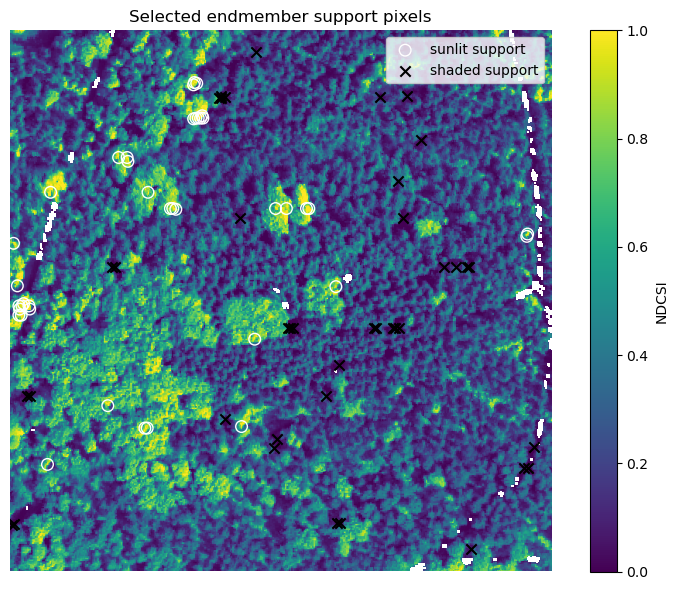

In [18]:
plt.figure(figsize=(8, 6))
plt.imshow(ndcsi, vmin=0, vmax=1)

sun_rows = [x[0] for x in sun_support]
sun_cols = [x[1] for x in sun_support]
shade_rows = [x[0] for x in shade_support]
shade_cols = [x[1] for x in shade_support]

plt.scatter(sun_cols, sun_rows, marker="o", facecolors="none", edgecolors="white", s=70, label="sunlit support")
plt.scatter(shade_cols, shade_rows, marker="x", c="black", s=55, label="shaded support")
plt.colorbar(label="NDCSI")
plt.legend(loc="best")
plt.title("Selected endmember support pixels")
plt.axis("off")
plt.tight_layout()
plt.show()

## 8. Build the endmembers

Sample the selected pixels and calculate the median sunlit and shaded spectra, with 10th–90th percentile ranges for QC.


In [19]:
sun_rows = np.asarray([x[0] for x in sun_support], dtype=int)
sun_cols = np.asarray([x[1] for x in sun_support], dtype=int)
shade_rows = np.asarray([x[0] for x in shade_support], dtype=int)
shade_cols = np.asarray([x[1] for x in shade_support], dtype=int)

sun_spectra = sample_spectra(BSQ_PATH, sun_rows, sun_cols, len(wavelengths))
shade_spectra = sample_spectra(BSQ_PATH, shade_rows, shade_cols, len(wavelengths))

sun_stats = robust_spectral_stats(sun_spectra, "sunlit")
shade_stats = robust_spectral_stats(shade_spectra, "shaded")

sun_endmember = sun_stats["median"]
shade_endmember = shade_stats["median"]

np.savez_compressed(
    OUT_DIR / "sun_shade_endmembers.npz",
    wavelengths=wavelengths.astype("float32"),
    sunlit=sun_endmember,
    shaded=shade_endmember,
    sunlit_p10=sun_stats["p10"],
    sunlit_p90=sun_stats["p90"],
    shaded_p10=shade_stats["p10"],
    shaded_p90=shade_stats["p90"],
    red_edge_wavelength_nm=np.asarray([red_edge_nm], dtype="float32"),
)

summary = {
    "source_bsq": str(BSQ_PATH),
    "source_hdr": str(HDR_PATH),
    "bands": int(len(wavelengths)),
    "wavelength_min_nm": float(wavelengths.min()),
    "wavelength_max_nm": float(wavelengths.max()),
    "analysis_domain": mask_description,
    "red_edge_wavelength_nm": red_edge_nm,
    "sun_ndcsi_threshold": sun_threshold,
    "shade_ndcsi_threshold": shade_threshold,
    "sun_support_n": sun_stats["n"],
    "shade_support_n": shade_stats["n"],
    "parameters": {
        "RED_RANGE": RED_RANGE,
        "NIR_RANGE": NIR_RANGE,
        "RED_EDGE_SEARCH_RANGE": RED_EDGE_SEARCH_RANGE,
        "NDCSI_LOW_QUANTILE": NDCSI_LOW_QUANTILE,
        "NDCSI_HIGH_QUANTILE": NDCSI_HIGH_QUANTILE,
        "SUN_NDCSI_QUANTILE": SUN_NDCSI_QUANTILE,
        "SHADE_NDCSI_QUANTILE": SHADE_NDCSI_QUANTILE,
        "ENDMEMBER_SUPPORT_SIZE": ENDMEMBER_SUPPORT_SIZE,
        "MIN_SPACING_PIXELS": MIN_SPACING_PIXELS,
        "UNMIXING_RANGE": UNMIXING_RANGE,
        "EXCLUDE_RANGES": EXCLUDE_RANGES,
    },
}
(OUT_DIR / "sun_shade_endmembers.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

print(f"Sunlit spectra used: {sun_stats['n']}")
print(f"Shaded spectra used: {shade_stats['n']}")
print(f"Saved endmember library to: {OUT_DIR}")

Sunlit spectra used: 40
Shaded spectra used: 40
Saved endmember library to: E:\Proj1_Pfynwald_Data\HyPlant\Kranzberg\output_sun_shade


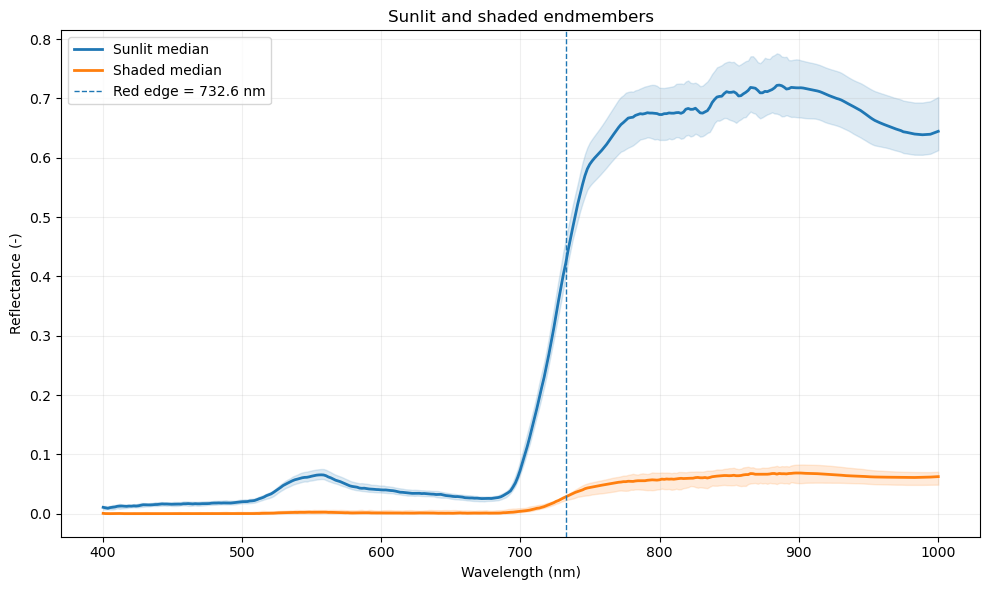

In [20]:
keep = (wavelengths >= 400) & (wavelengths <= 1100)

fig, ax = plt.subplots(figsize=(10, 6))

line = ax.plot(wavelengths[keep], sun_endmember[keep], linewidth=2, label="Sunlit median")[0]
ax.fill_between(
    wavelengths[keep], sun_stats["p10"][keep], sun_stats["p90"][keep],
    alpha=0.15, color=line.get_color()
)

line = ax.plot(wavelengths[keep], shade_endmember[keep], linewidth=2, label="Shaded median")[0]
ax.fill_between(
    wavelengths[keep], shade_stats["p10"][keep], shade_stats["p90"][keep],
    alpha=0.15, color=line.get_color()
)

ax.axvline(red_edge_nm, linestyle="--", linewidth=1, label=f"Red edge = {red_edge_nm:.1f} nm")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance (-)")
ax.set_title("Sunlit and shaded endmembers")
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "endmember_spectra.png", dpi=200)
plt.show()

## 9. Two-endmember linear unmixing

Each forest/vegetation pixel is projected onto the line between the shaded and sunlit endmembers. `f_sun_veg` is clipped to 0–1 and RMSE is saved as a fit-quality diagnostic.


In [21]:
def unmixing_band_indices(wavelengths):
    wl = np.asarray(wavelengths, dtype=float)
    keep = (wl >= UNMIXING_RANGE[0]) & (wl <= UNMIXING_RANGE[1])
    for low, high in EXCLUDE_RANGES:
        keep &= ~((wl >= low) & (wl <= high))
    idx = np.flatnonzero(keep)
    if idx.size < 2:
        raise ValueError("Too few wavelength bands remain for unmixing.")
    return idx


band_idx = unmixing_band_indices(wavelengths)
sun = sun_endmember[band_idx].astype("float64")
shade = shade_endmember[band_idx].astype("float64")

finite_endmembers = np.isfinite(sun) & np.isfinite(shade)
band_idx = band_idx[finite_endmembers]
sun = sun[finite_endmembers]
shade = shade[finite_endmembers]

if band_idx.size < 2:
    raise ValueError("Too few finite endmember bands remain for unmixing.")

direction = sun - shade
denom = float(np.dot(direction, direction))
if not np.isfinite(denom) or denom <= 1e-12:
    raise ValueError("Sunlit and shaded endmembers are spectrally indistinguishable.")

height, width = analysis_mask.shape
f_sun = np.full((height, width), np.nan, dtype="float32")
rmse = np.full((height, width), np.nan, dtype="float32")

with rasterio.open(BSQ_PATH) as src:
    raster_bands = (band_idx + 1).tolist()  # Rasterio is 1-based for band numbers.

    for y0 in range(0, height, BLOCK_ROWS):
        y1 = min(height, y0 + BLOCK_ROWS)
        window = Window(0, y0, width, y1 - y0)

        raw = src.read(raster_bands, window=window)
        block = scaled_reflectance(raw, src.nodata).astype("float64")

        block_h = y1 - y0
        Y = block.reshape(block.shape[0], -1)
        valid_pix = np.all(np.isfinite(Y), axis=0)
        valid_pix &= analysis_mask[y0:y1, :].reshape(-1)

        if not np.any(valid_pix):
            continue

        Yv = Y[:, valid_pix]
        f = direction @ (Yv - shade[:, None]) / denom
        f = np.clip(f, 0.0, 1.0)

        prediction = shade[:, None] + direction[:, None] * f[None, :]
        rmse_v = np.sqrt(np.mean((Yv - prediction) ** 2, axis=0))

        flat_f = np.full(block_h * width, np.nan, dtype="float32")
        flat_rmse = np.full(block_h * width, np.nan, dtype="float32")
        flat_f[valid_pix] = f.astype("float32")
        flat_rmse[valid_pix] = rmse_v.astype("float32")

        f_sun[y0:y1, :] = flat_f.reshape(block_h, width)
        rmse[y0:y1, :] = flat_rmse.reshape(block_h, width)

write_single_band_tif(
    OUT_DIR / "f_sun_veg.tif",
    f_sun,
    "sunlit fraction along the two-endmember vegetation illumination line",
)
write_single_band_tif(
    OUT_DIR / "rmse.tif",
    rmse,
    "two-endmember spectral fit RMSE",
)

valid_fraction = np.isfinite(f_sun)
if np.any(valid_fraction):
    pct_zero = 100 * np.mean(f_sun[valid_fraction] <= 1e-6)
    pct_one = 100 * np.mean(f_sun[valid_fraction] >= 1 - 1e-6)
    print(f"Valid unmixed vegetation pixels: {int(valid_fraction.sum())}")
    print(f"Pixels clipped to f_sun = 0: {pct_zero:.1f}%")
    print(f"Pixels clipped to f_sun = 1: {pct_one:.1f}%")
    print(f"Median RMSE: {np.nanmedian(rmse):.5f}")

print(f"Saved: {OUT_DIR / 'f_sun_veg.tif'}")
print(f"Saved: {OUT_DIR / 'rmse.tif'}")

Valid unmixed vegetation pixels: 488080
Pixels clipped to f_sun = 0: 0.6%
Pixels clipped to f_sun = 1: 0.2%
Median RMSE: 0.00553
Saved: E:\Proj1_Pfynwald_Data\HyPlant\Kranzberg\output_sun_shade\f_sun_veg.tif
Saved: E:\Proj1_Pfynwald_Data\HyPlant\Kranzberg\output_sun_shade\rmse.tif


## 10. Inspect the results

Check that bright crowns have higher `f_sun_veg`, shaded crowns have lower values, and poorly represented pixels show higher RMSE.


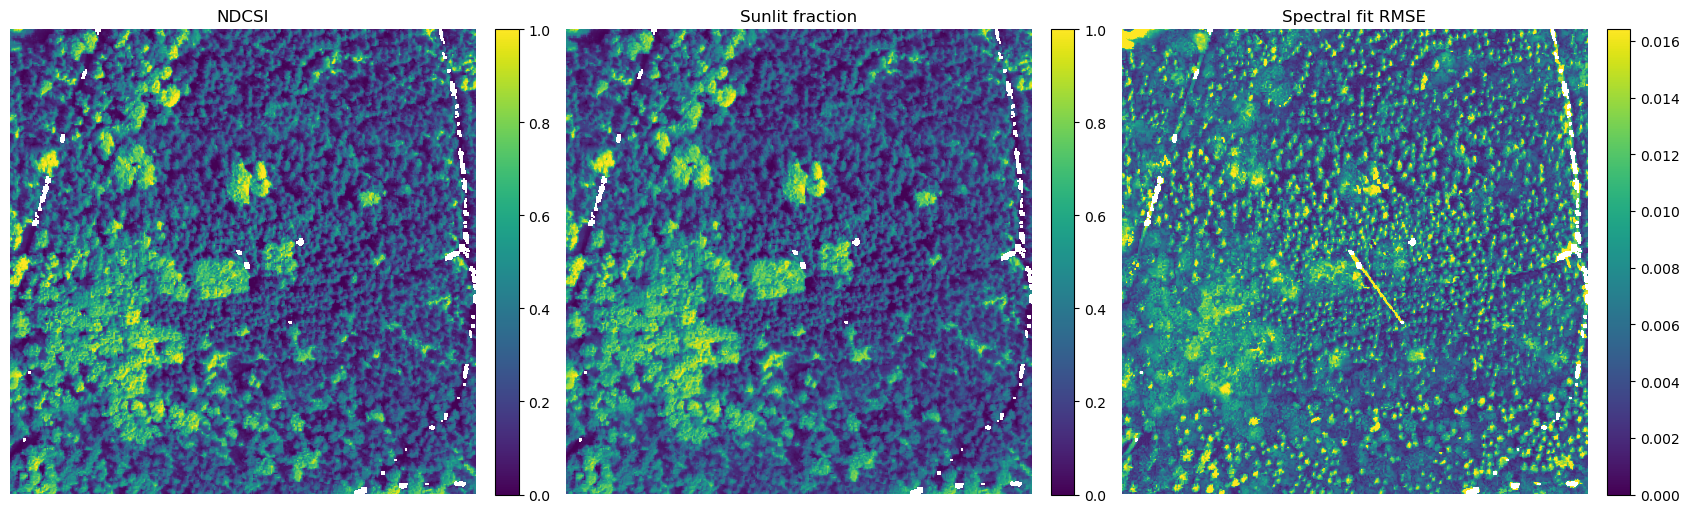

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

im = axes[0].imshow(ndcsi, vmin=0, vmax=1)
axes[0].set_title("NDCSI")
axes[0].axis("off")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

im = axes[1].imshow(f_sun, vmin=0, vmax=1)
axes[1].set_title("Sunlit fraction")
axes[1].axis("off")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

# Robust display stretch only; the saved RMSE raster retains the original values.
rmse_max = np.nanpercentile(rmse, 98) if np.any(np.isfinite(rmse)) else 1.0
im = axes[2].imshow(rmse, vmin=0, vmax=rmse_max)
axes[2].set_title("Spectral fit RMSE")
axes[2].axis("off")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(OUT_DIR / "illumination_maps.png", dpi=200)
plt.show()

## 11. Minimum validation

Before using the fractions, check:

- `endmember_support_pixels.gpkg` in QGIS;
- the sunlit and shaded endmember spectra;
- the spatial pattern of `f_sun_veg`;
- the RMSE map.

Main outputs are `NDCSI.tif`, `f_sun_veg.tif`, `rmse.tif`, the support-pixel GeoPackage, and the saved endmember spectra.
